In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd

df = pd.read_csv(
    "/mnt/c/Users/manav/OneDrive/Desktop/paitent health/Patient_Health_Records_Cleaned.csv"
)

print(df.head())

    Age  Gender         City   BMI  Heart_Rate  Cholesterol_Level  Diabetic  \
0  48.0       0       Boston  22.5        83.0              190.0         0   
1  48.0       0     New York  25.8        87.0              190.0         0   
2  48.0       0     New York  22.5        87.0              190.0         0   
3  80.0       0     New York  33.4        87.0              250.0         1   
4  48.0       1  Los Angeles  30.1        87.0              190.0         0   

   Smoker         Medications  Follow_Up Diagnosis_Code Has_Disease  \
0       1             Unknown       30.0            A00           0   
1       0             Unknown       14.0        Unknown     Unknown   
2       1  Aspirin; Metformin       30.0            B20     Unknown   
3       1             Unknown       30.0        Unknown     Unknown   
4       0             Unknown       14.0            I10           1   

   Systolic_BP  Diastolic_BP  
0        120.0          80.0  
1        120.0          80.0  
2    

In [3]:
df_ml = df.copy()

In [4]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 9494 entries, 0 to 9493
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                9494 non-null   float64
 1   Gender             9494 non-null   int64  
 2   City               9494 non-null   str    
 3   BMI                9494 non-null   float64
 4   Heart_Rate         9494 non-null   float64
 5   Cholesterol_Level  9494 non-null   float64
 6   Diabetic           9494 non-null   int64  
 7   Smoker             9494 non-null   int64  
 8   Medications        9494 non-null   str    
 9   Follow_Up          9494 non-null   float64
 10  Diagnosis_Code     9494 non-null   str    
 11  Has_Disease        9494 non-null   str    
 12  Systolic_BP        9494 non-null   float64
 13  Diastolic_BP       9494 non-null   float64
dtypes: float64(7), int64(3), str(4)
memory usage: 1.0 MB


In [15]:
for col in categorical_cols:

    print(f"\n========== {col} ==========")
    print(df_ml[col].value_counts(dropna=False))


========== City ==========
City
New York       3721
Chicago        1939
Los Angeles    1851
Boston         1007
Unknown         976
Name: count, dtype: int64

========== Medications ==========
Medications
Unknown                  3811
Aspirin; Metformin       3740
Lisinopril; Metformin    1943
Name: count, dtype: int64

========== Diagnosis_Code ==========
Diagnosis_Code
Unknown    3142
B20        1625
E11.9      1590
I10        1589
A00        1548
Name: count, dtype: int64


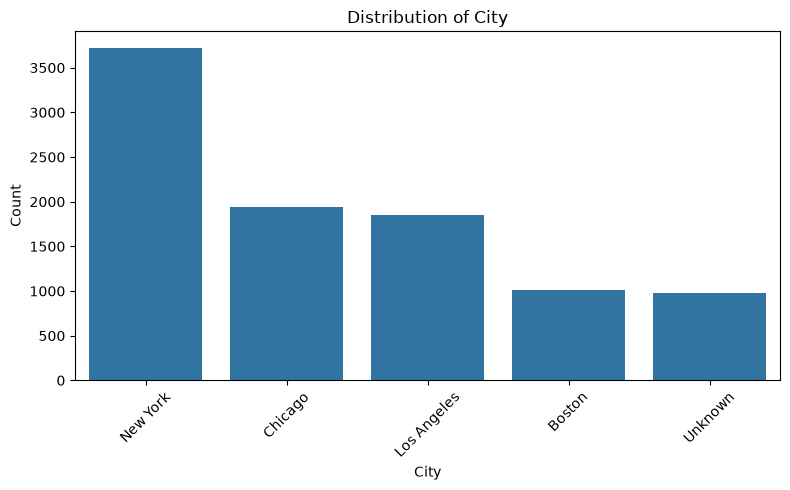

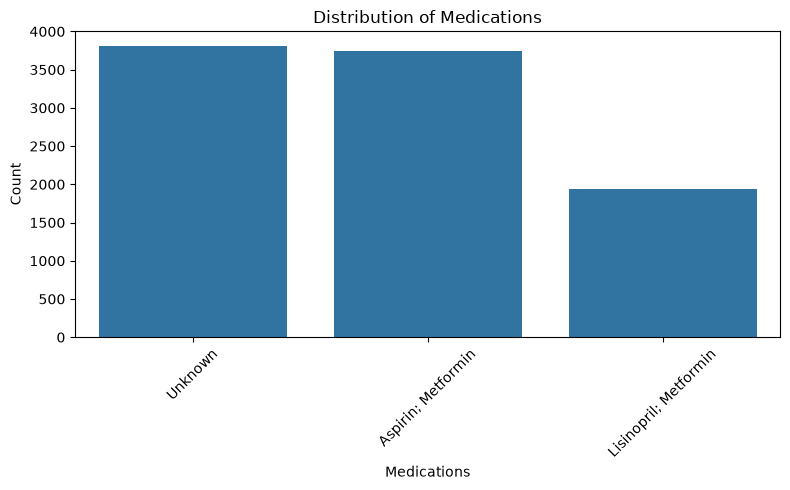

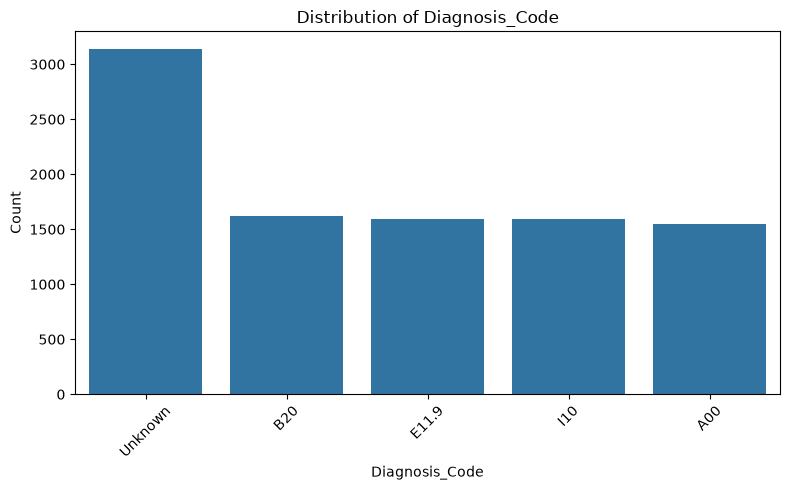

In [16]:
for col in categorical_cols:

    plt.figure(figsize=(8, 5))

    order = df_ml[col].value_counts().index

    sns.countplot(
        data=df_ml,
        x=col,
        order=order
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [18]:
print(df_ml['Has_Disease'].value_counts())

Has_Disease
Unknown    4684
0          2424
1          2386
Name: count, dtype: int64


In [19]:
target_percent = (
    df_ml['Has_Disease']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percent)

Has_Disease
Unknown    49.34
0          25.53
1          25.13
Name: proportion, dtype: float64


In [21]:
# Create ML copy
df_ml = df.copy()

# Standardize Unknown values
df_ml['Has_Disease'] = df_ml['Has_Disease'].astype(str).str.strip()

df_ml['Has_Disease'] = df_ml['Has_Disease'].replace({
    'unknown': 'Unknown',
    'UNKNOWN': 'Unknown',
    'Unknown': 'Unknown'
})

# Remove Unknown target rows
df_ml = df_ml[df_ml['Has_Disease'] != 'Unknown'].copy()

# Check result
print(df_ml['Has_Disease'].value_counts())
print(df_ml.shape)

Has_Disease
0    2424
1    2386
Name: count, dtype: int64
(4810, 14)


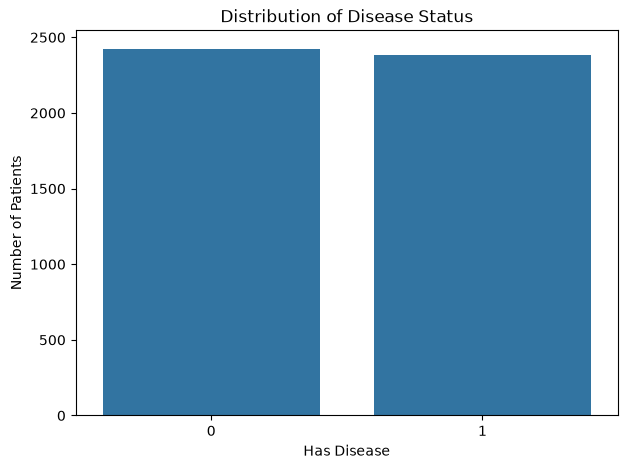

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_ml,
    x='Has_Disease'
)

plt.title('Distribution of Disease Status')
plt.xlabel('Has Disease')
plt.ylabel('Number of Patients')

plt.show()

In [23]:
print("=" * 60)
print("                 EDA SUMMARY")
print("=" * 60)

print("\nDataset:")
print(f"Rows: {df_ml.shape[0]}")
print(f"Columns: {df_ml.shape[1]}")

print("\nMissing Values:")
print(df_ml.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_ml.duplicated().sum())

print("\nNumerical Features:")
print(len(numeric_cols))
print(numeric_cols)

print("\nCategorical Features:")
print(len(categorical_cols))
print(categorical_cols)

print("\nTarget Distribution:")
print(df_ml['Has_Disease'].value_counts())

print("\nTarget Percentage:")
print(
    df_ml['Has_Disease']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("=" * 60)

                 EDA SUMMARY

Dataset:
Rows: 4810
Columns: 14

Missing Values:
0

Duplicate Rows:
429

Numerical Features:
10
['Age', 'Gender', 'BMI', 'Heart_Rate', 'Cholesterol_Level', 'Diabetic', 'Smoker', 'Follow_Up', 'Systolic_BP', 'Diastolic_BP']

Categorical Features:
3
['City', 'Medications', 'Diagnosis_Code']

Target Distribution:
Has_Disease
0    2424
1    2386
Name: count, dtype: int64

Target Percentage:
Has_Disease
0    50.4
1    49.6
Name: proportion, dtype: float64


In [24]:
print("Duplicate Rows:", df_ml.duplicated().sum())

Duplicate Rows: 429


In [25]:
df_ml = df_ml.drop_duplicates().copy()

In [26]:
print("Duplicate Rows:", df_ml.duplicated().sum())


Duplicate Rows: 0


In [28]:
df_ml.shape

(4381, 14)

In [29]:
df_ml.info()

<class 'pandas.DataFrame'>
Index: 4381 entries, 0 to 9492
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                4381 non-null   float64
 1   Gender             4381 non-null   int64  
 2   City               4381 non-null   str    
 3   BMI                4381 non-null   float64
 4   Heart_Rate         4381 non-null   float64
 5   Cholesterol_Level  4381 non-null   float64
 6   Diabetic           4381 non-null   int64  
 7   Smoker             4381 non-null   int64  
 8   Medications        4381 non-null   str    
 9   Follow_Up          4381 non-null   float64
 10  Diagnosis_Code     4381 non-null   str    
 11  Has_Disease        4381 non-null   str    
 12  Systolic_BP        4381 non-null   float64
 13  Diastolic_BP       4381 non-null   float64
dtypes: float64(7), int64(3), str(4)
memory usage: 513.4 KB


In [31]:
print("========== DATA QUALITY CHECK ==========")

print("\nDataset Shape:")
print(df_ml.shape)

print("\nMissing Values:")
print(df_ml.isnull().sum())

print("\nTotal Missing Values:")
print(df_ml.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_ml.duplicated().sum())

print("\nTarget Distribution:")
print(df_ml['Has_Disease'].value_counts(dropna=False))

print("\n========================================")

========== DATA QUALITY CHECK ==========

Dataset Shape:
(4381, 14)

Missing Values:
Age                  0
Gender               0
City                 0
BMI                  0
Heart_Rate           0
Cholesterol_Level    0
Diabetic             0
Smoker               0
Medications          0
Follow_Up            0
Diagnosis_Code       0
Has_Disease          0
Systolic_BP          0
Diastolic_BP         0
dtype: int64

Total Missing Values:
0

Duplicate Rows:
0

Target Distribution:
Has_Disease
0    2209
1    2172
Name: count, dtype: int64



In [32]:
numeric_cols = df_ml.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df_ml.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

# Remove target from categorical feature list
if 'Has_Disease' in categorical_cols:
    categorical_cols.remove('Has_Disease')

print("Numerical Features:")
print(numeric_cols)

print("\nCategorical Features:")
print(categorical_cols)

Numerical Features:
['Age', 'Gender', 'BMI', 'Heart_Rate', 'Cholesterol_Level', 'Diabetic', 'Smoker', 'Follow_Up', 'Systolic_BP', 'Diastolic_BP']

Categorical Features:
['City', 'Medications', 'Diagnosis_Code']


/tmp/ipykernel_4732/2876584658.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_ml.select_dtypes(


In [33]:
print("========== NUMERICAL SUMMARY ==========")

display(df_ml[numeric_cols].describe().T)

========== NUMERICAL SUMMARY ==========


,count,mean,std,min,25%,50%,75%,max
Age,4381.0,50.539831,12.524262,18.0,48.0,48.0,48.0,100.0
Gender,4381.0,0.343301,0.474865,0.0,0.0,0.0,1.0,1.0
BMI,4381.0,23.135152,3.211290,15.0,22.5,22.5,22.5,35.0
Heart_Rate,4381.0,86.433919,11.113652,50.0,87.0,87.0,87.0,120.0
Cholesterol_Level,4381.0,202.709427,24.518836,190.0,190.0,190.0,190.0,250.0
Diabetic,4381.0,0.337594,0.472943,0.0,0.0,0.0,1.0,1.0
Smoker,4381.0,0.505821,0.500023,0.0,0.0,1.0,1.0,1.0
Follow_Up,4381.0,18.101347,6.986533,14.0,14.0,14.0,30.0,30.0
Systolic_BP,4381.0,121.104542,10.001234,90.0,120.0,120.0,120.0,160.0
Diastolic_BP,4381.0,80.026250,5.761983,60.0,80.0,80.0,80.0,100.0


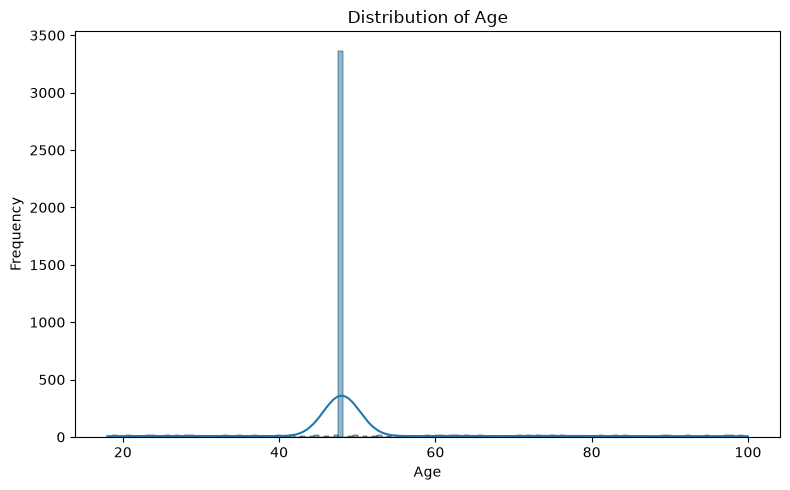

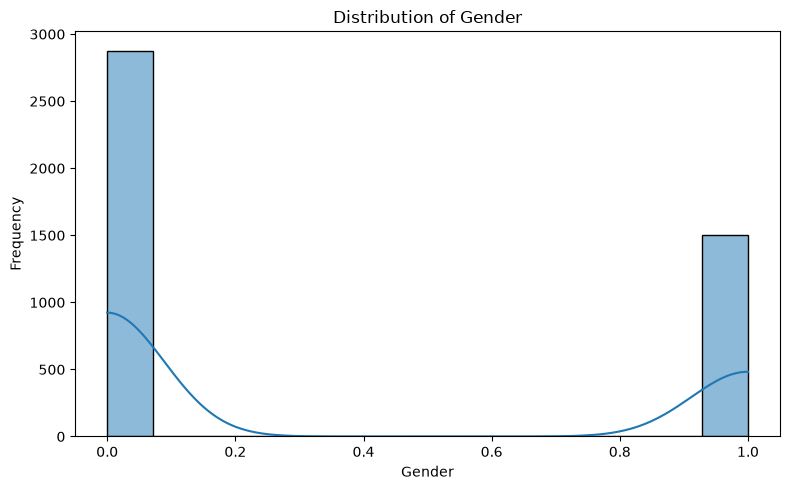

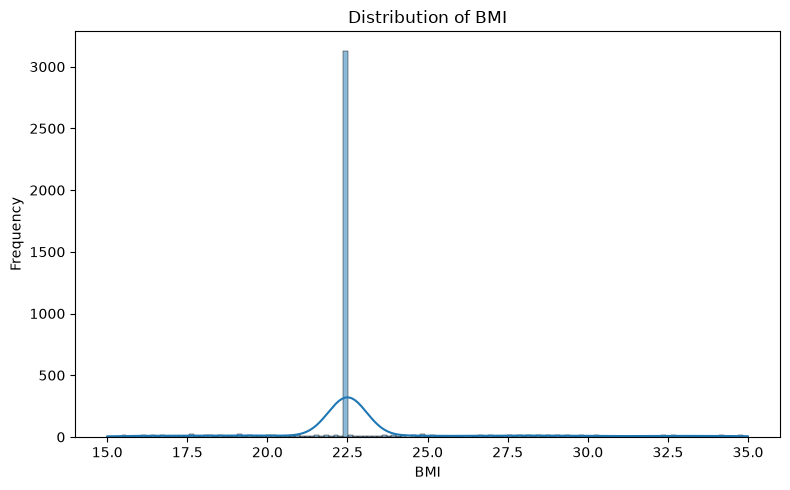

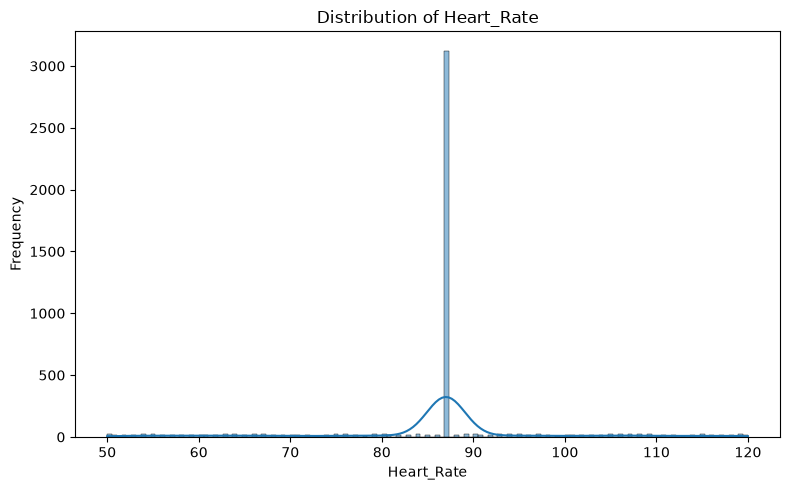

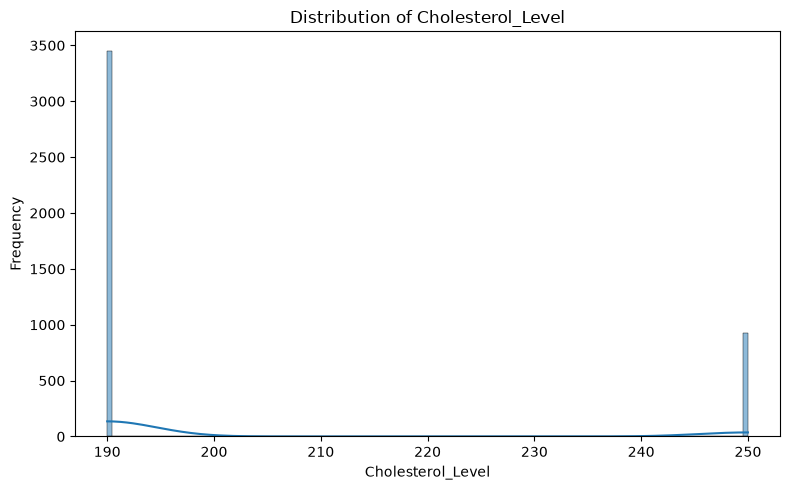

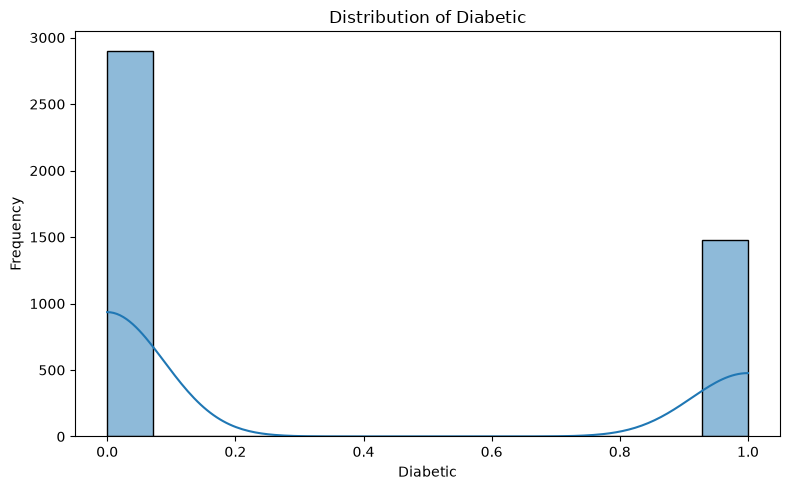

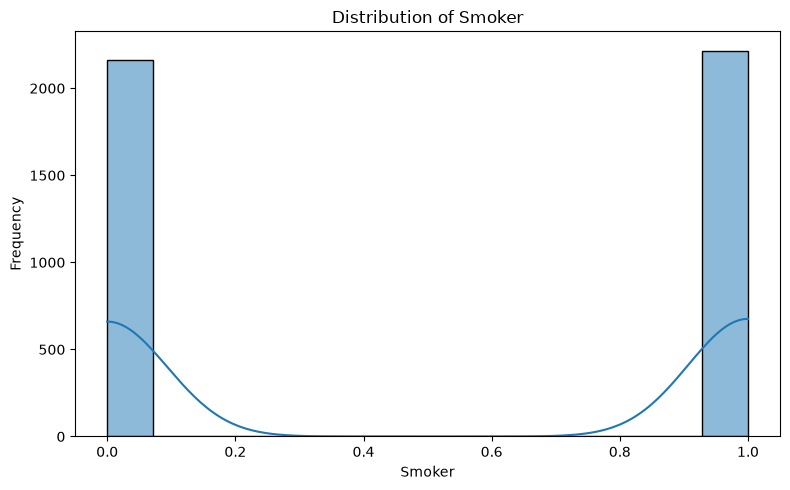

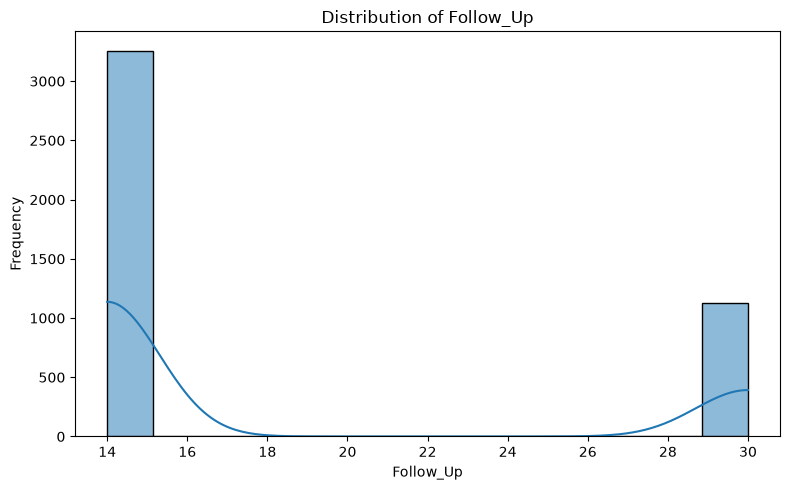

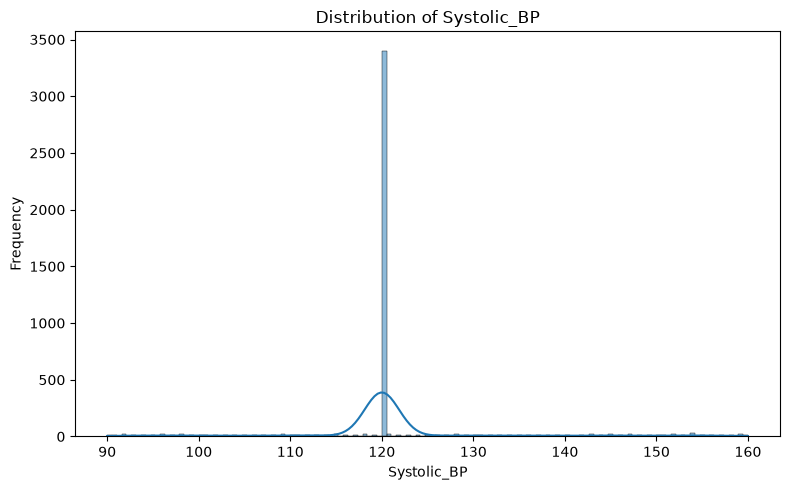

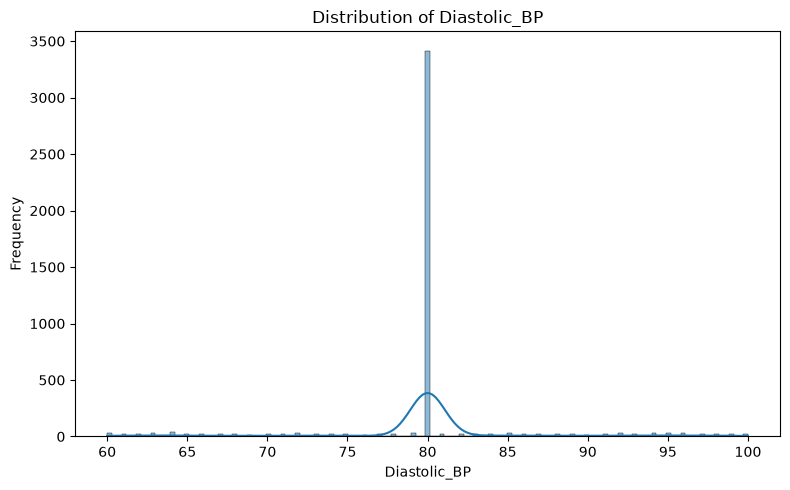

In [34]:
for col in numeric_cols:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df_ml,
        x=col,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

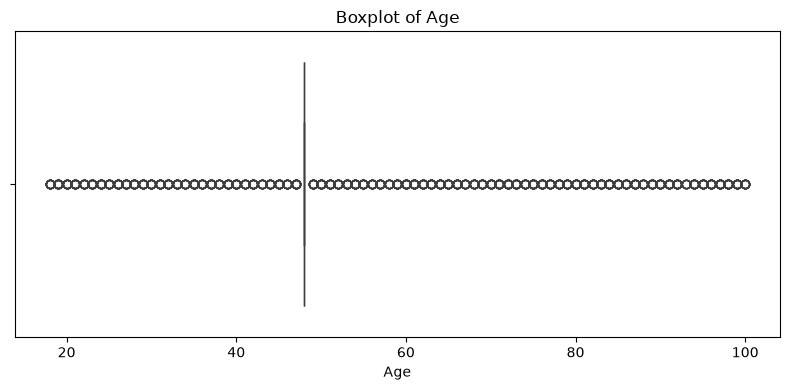

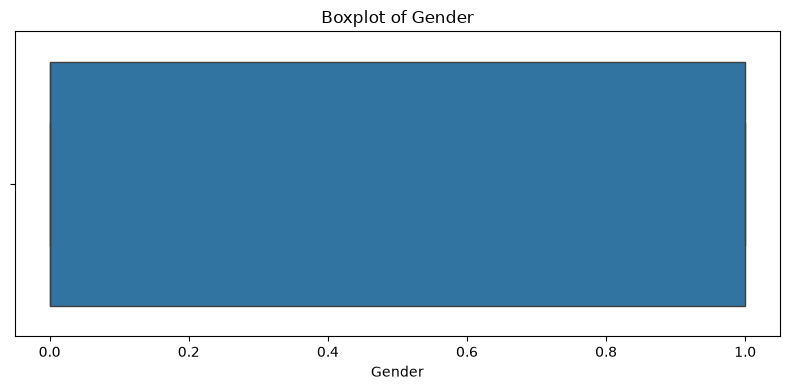

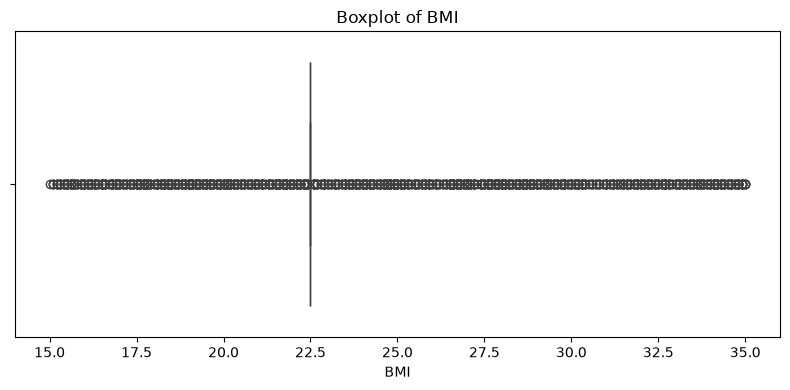

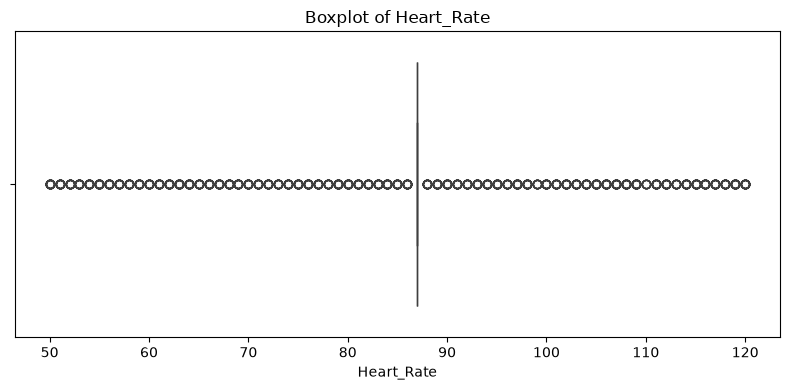

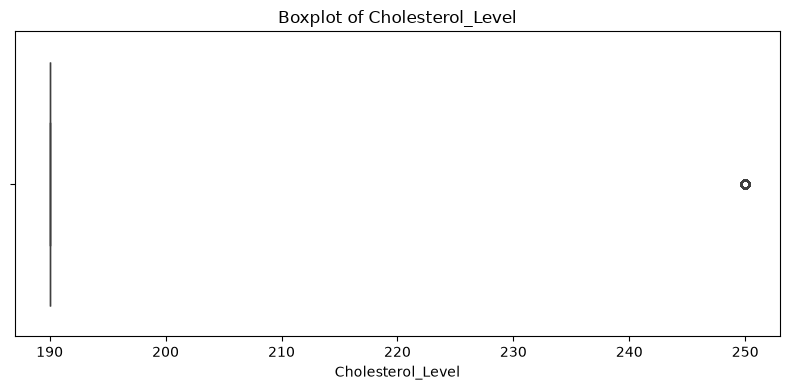

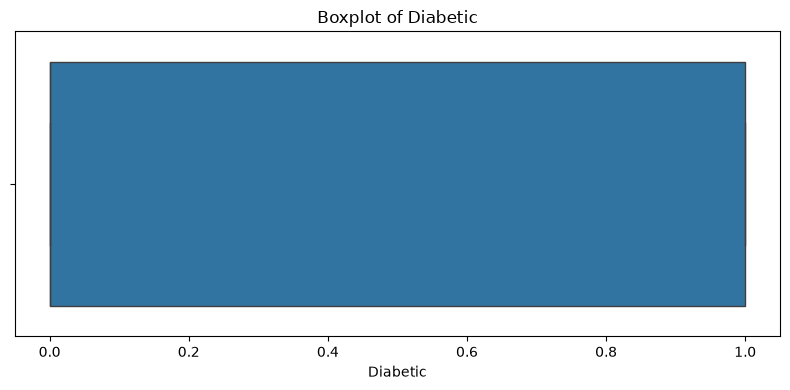

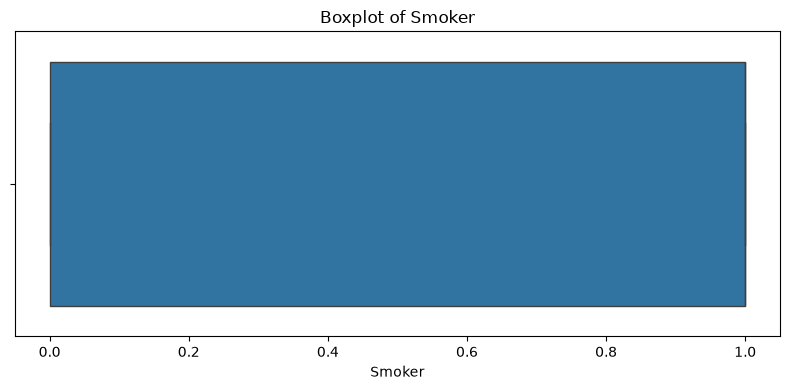

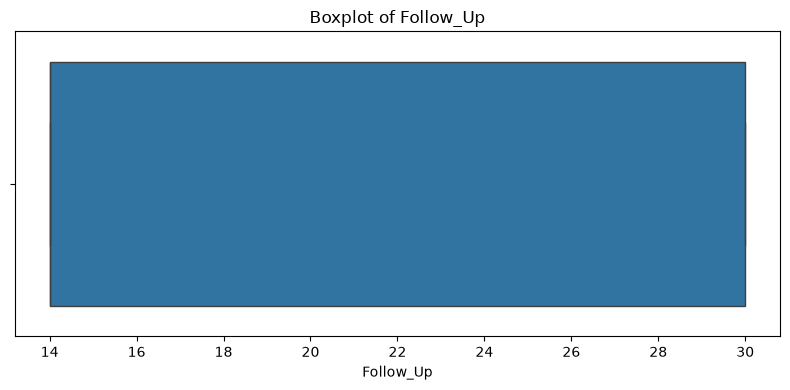

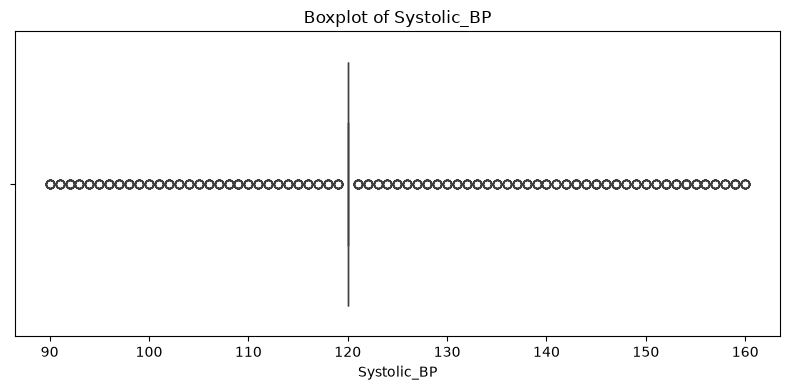

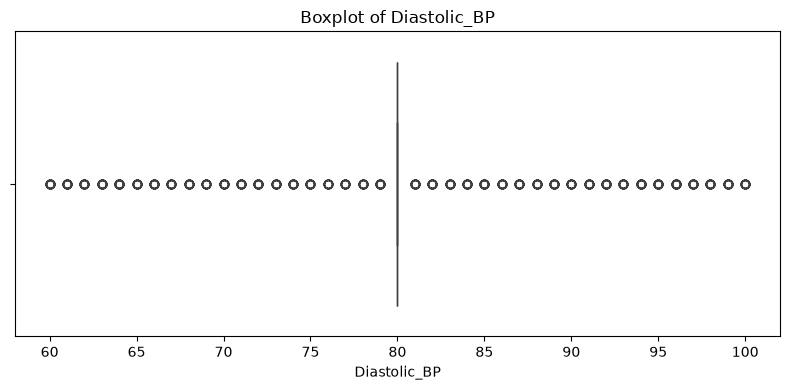

In [35]:
for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df_ml,
        x=col
    )

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [36]:
for col in categorical_cols:

    print(f"\n========== {col} ==========")
    print(df_ml[col].value_counts(dropna=False))


========== City ==========
City
New York       1659
Chicago         913
Los Angeles     848
Unknown         506
Boston          455
Name: count, dtype: int64

========== Medications ==========
Medications
Unknown                  1738
Aspirin; Metformin       1723
Lisinopril; Metformin     920
Name: count, dtype: int64

========== Diagnosis_Code ==========
Diagnosis_Code
Unknown    1447
B20         797
E11.9       719
I10         717
A00         701
Name: count, dtype: int64


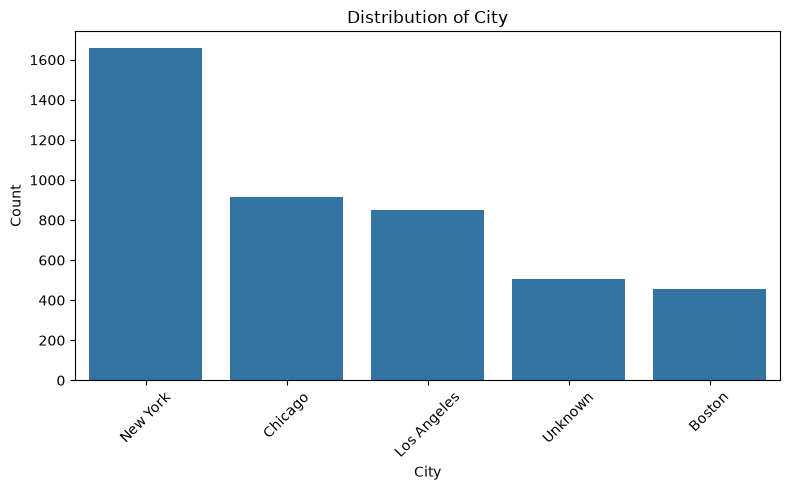

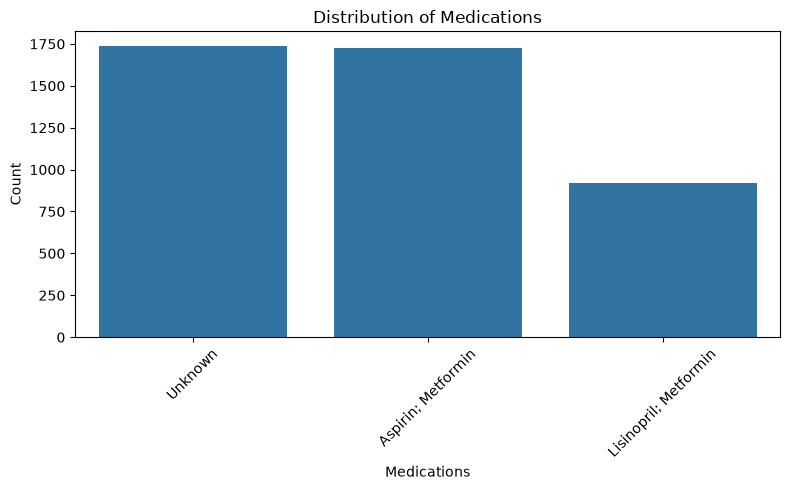

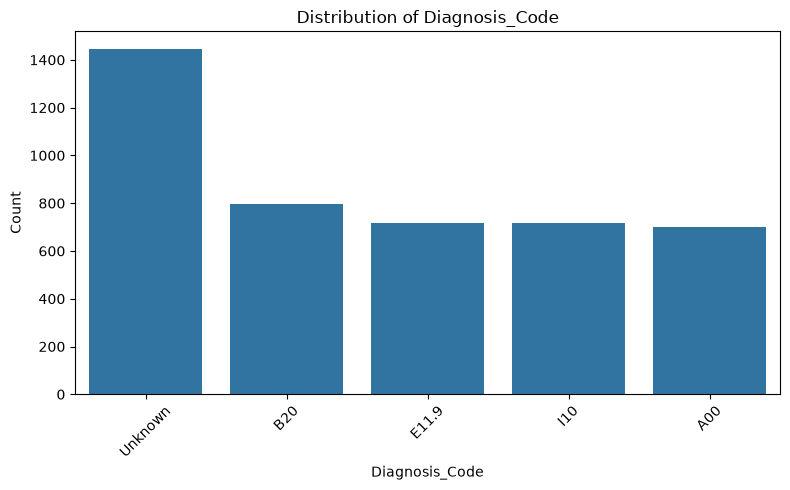

In [37]:
for col in categorical_cols:

    plt.figure(figsize=(8, 5))

    order = df_ml[col].value_counts().index

    sns.countplot(
        data=df_ml,
        x=col,
        order=order
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [38]:
print(df_ml['Has_Disease'].value_counts())

Has_Disease
0    2209
1    2172
Name: count, dtype: int64


In [39]:
target_percent = (
    df_ml['Has_Disease']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percent)

Has_Disease
0    50.42
1    49.58
Name: proportion, dtype: float64


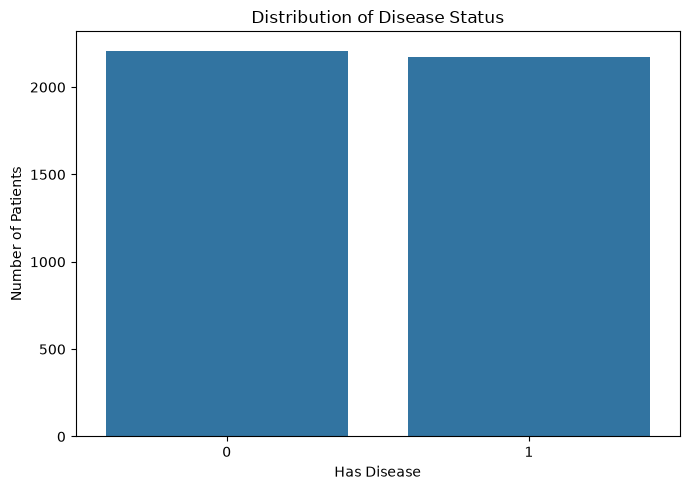

In [40]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_ml,
    x='Has_Disease',
    order=df_ml['Has_Disease'].value_counts().index
)

plt.title('Distribution of Disease Status')
plt.xlabel('Has Disease')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

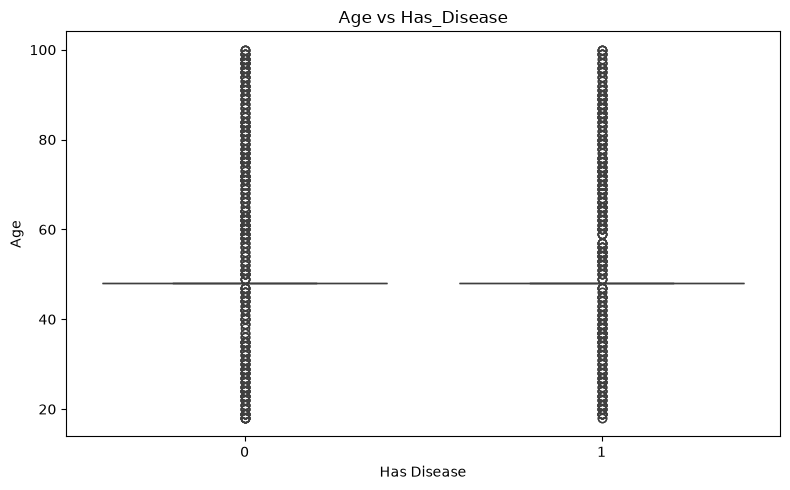

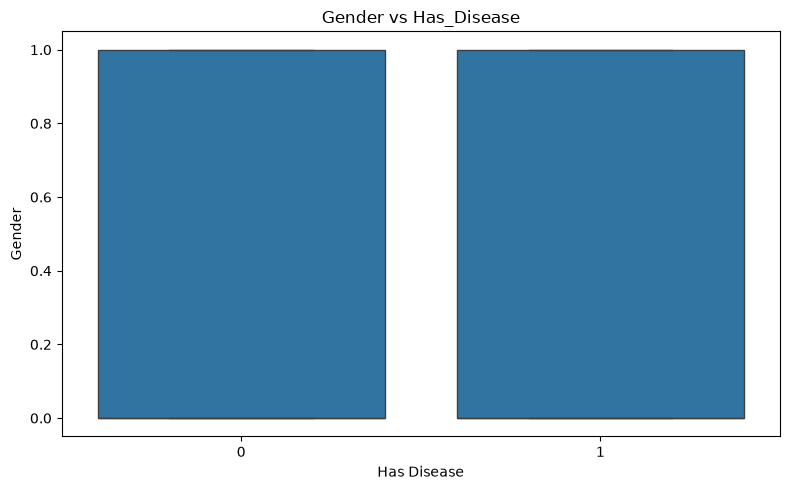

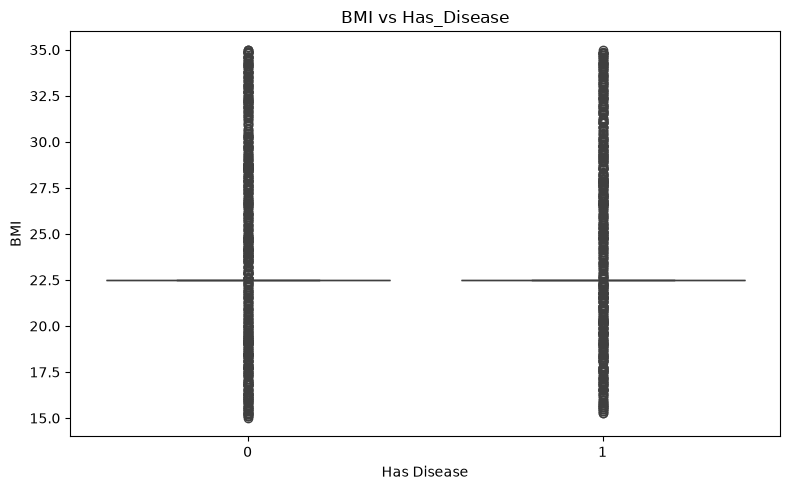

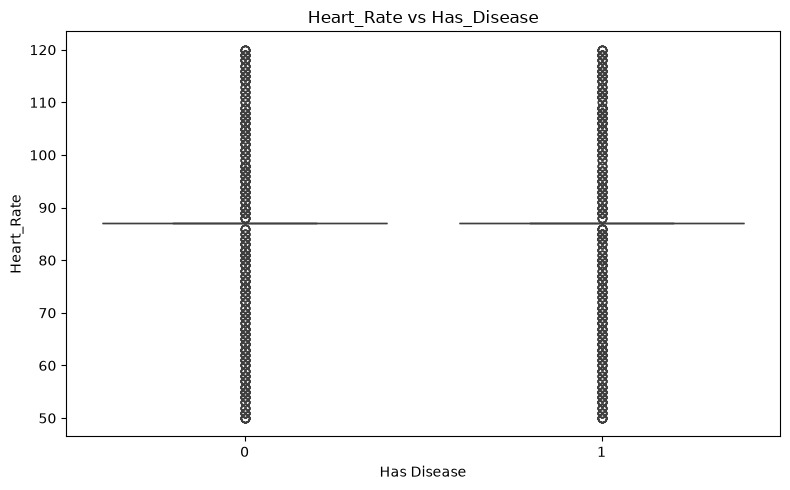

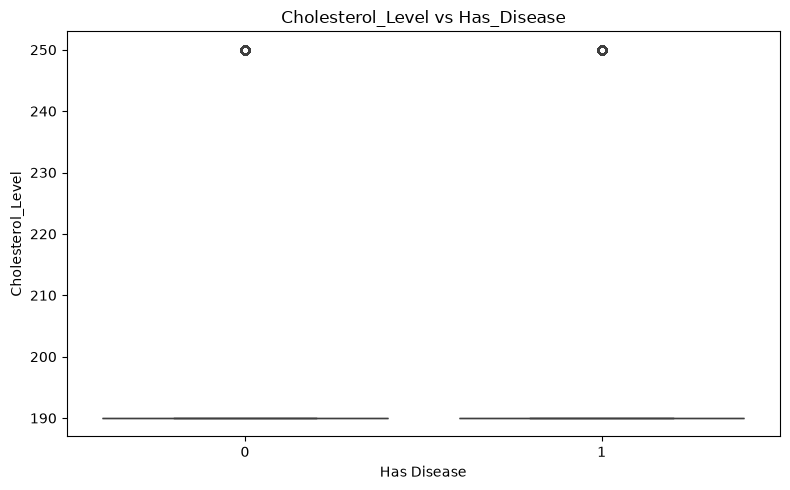

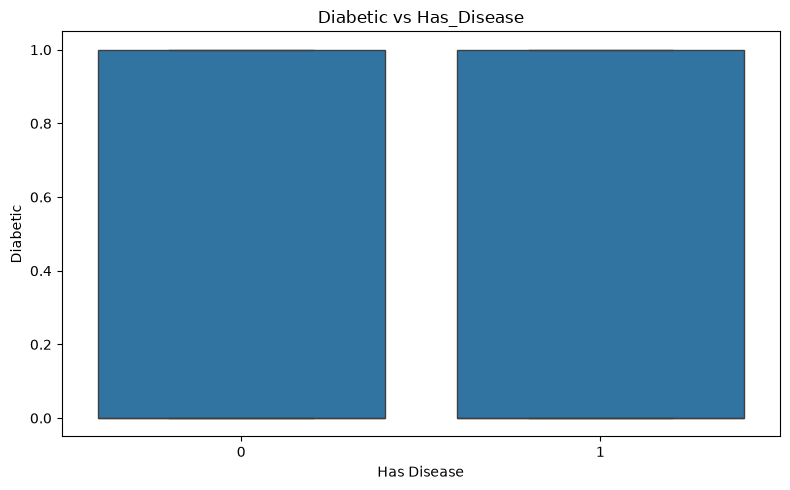

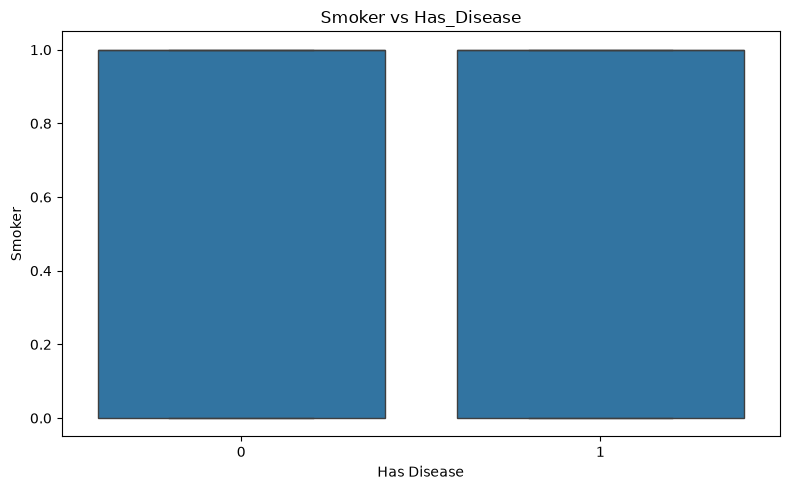

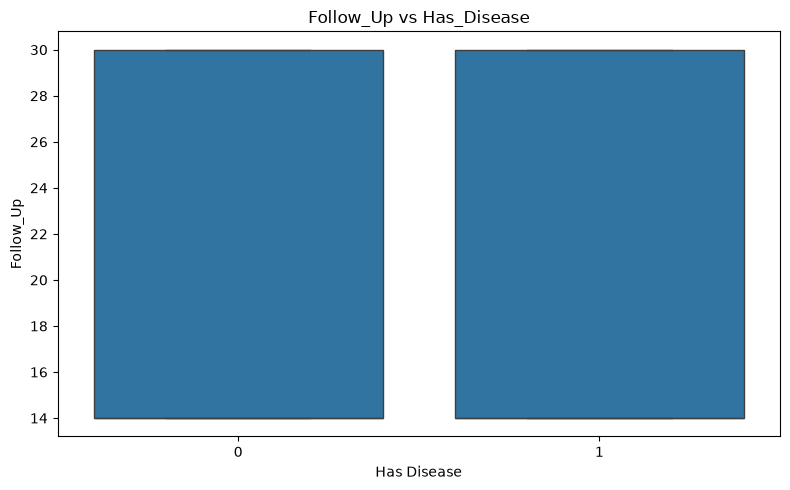

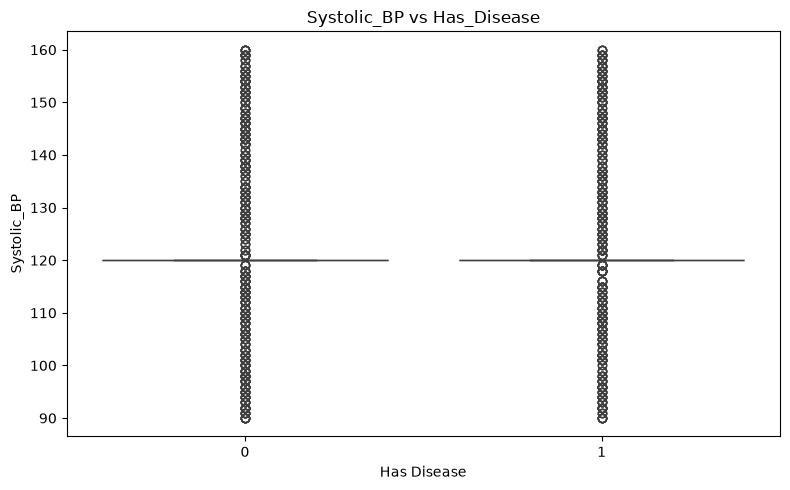

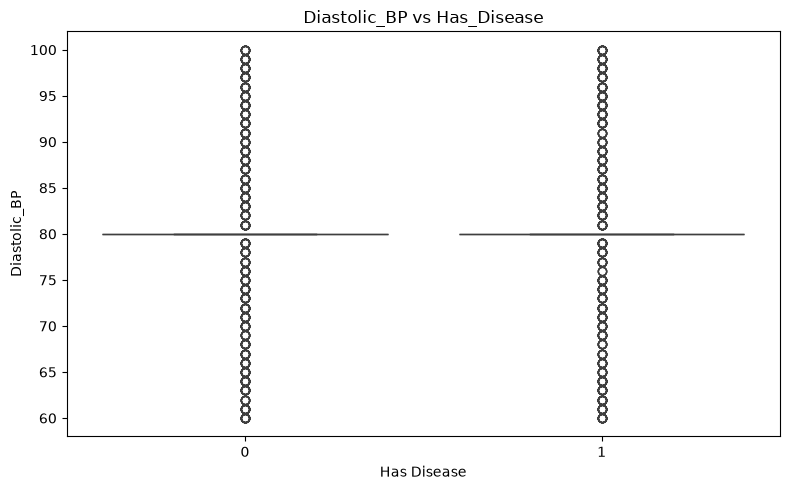

In [41]:
for col in numeric_cols:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df_ml,
        x='Has_Disease',
        y=col
    )

    plt.title(f'{col} vs Has_Disease')
    plt.xlabel('Has Disease')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()